# Assignment 1
## Daniel Mehta

In [53]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("bc.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample code number           699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class Label                  699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [16]:
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')
df.dropna(inplace=True)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump Thickness              683 non-null    int64  
 1   Uniformity of Cell Size      683 non-null    int64  
 2   Uniformity of Cell Shape     683 non-null    int64  
 3   Marginal Adhesion            683 non-null    int64  
 4   Single Epithelial Cell Size  683 non-null    int64  
 5   Bare Nuclei                  683 non-null    float64
 6   Bland Chromatin              683 non-null    int64  
 7   Normal Nucleoli              683 non-null    int64  
 8   Mitoses                      683 non-null    int64  
 9   Class Label                  683 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 58.7 KB


,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class Label
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


## Question 1

In [21]:
X = df.drop('Class Label', axis=1)
y = df['Class Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (546, 9)
Test size: (137, 9)


## Question 2

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("-"*55)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[78  1]
 [ 5 53]]
-------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           2       0.94      0.99      0.96        79
           4       0.98      0.91      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137



## Question 3

In [49]:
df = df[df['Class Label'].isin([2, 4])]

true_labels = df['Class Label'].map({2: 0, 4: 1})
pred_labels = df['Cluster Label']

print("Confusion Matrix:\n", confusion_matrix(true_labels, pred_labels))
print("-"*55)
print("\nClassification Report:\n", classification_report(true_labels, pred_labels, zero_division=1))

Confusion Matrix:
 [[  9 435]
 [221  18]]
-------------------------------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.04      0.02      0.03       444
           1       0.04      0.08      0.05       239

    accuracy                           0.04       683
   macro avg       0.04      0.05      0.04       683
weighted avg       0.04      0.04      0.04       683



## Question 4

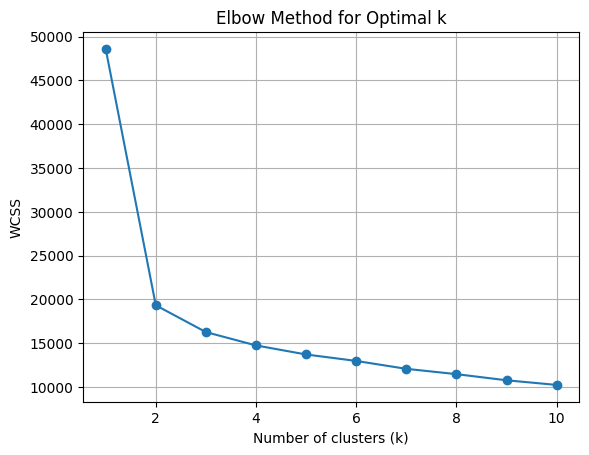

In [60]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_cluster)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

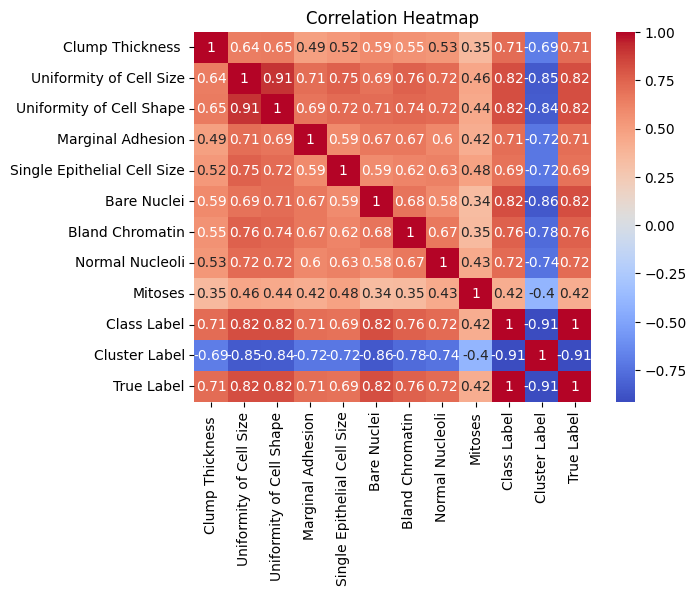

In [65]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [62]:
print("Final Dataset Shape:", df.shape)
print("-"*55)
print("Class Distribution:\n", df['Class Label'].value_counts())

Final Dataset Shape: (683, 12)
-------------------------------------------------------
Class Distribution:
 Class Label
2    444
4    239
Name: count, dtype: int64
